In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

In [6]:
sns.set_theme(style='whitegrid')
df = sns.load_dataset("titanic")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None


In [ ]:
print(df.describe(include="all"))

          survived      pclass   sex         age       sibsp       parch  \
count   891.000000  891.000000   891  714.000000  891.000000  891.000000   
unique         NaN         NaN     2         NaN         NaN         NaN   
top            NaN         NaN  male         NaN         NaN         NaN   
freq           NaN         NaN   577         NaN         NaN         NaN   
mean      0.383838    2.308642   NaN   29.699118    0.523008    0.381594   
std       0.486592    0.836071   NaN   14.526497    1.102743    0.806057   
min       0.000000    1.000000   NaN    0.420000    0.000000    0.000000   
25%       0.000000    2.000000   NaN   20.125000    0.000000    0.000000   
50%       0.000000    3.000000   NaN   28.000000    0.000000    0.000000   
75%       1.000000    3.000000   NaN   38.000000    1.000000    0.000000   
max       1.000000    3.000000   NaN   80.000000    8.000000    6.000000   

              fare embarked  class  who adult_male deck  embark_town alive  \
count   8

In [35]:
print("\n--- missing value count----")
print(df.isnull().sum())


--- missing value count----
survived         0
pclass           0
sex              0
age              0
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck           688
embark_town      0
alive            0
alone            0
family_size      0
dtype: int64


In [29]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

In [30]:
df["age"] = df["age"].fillna(df["age"].median())

In [31]:
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

In [32]:
df["embark_town"] = df["embark_town"].fillna(df["embark_town"].mode()[0])

In [34]:
df["family_size"] = df["sibsp"] + df["parch"] + 1


In [ ]:
sns.set_theme(style="whitegrid")


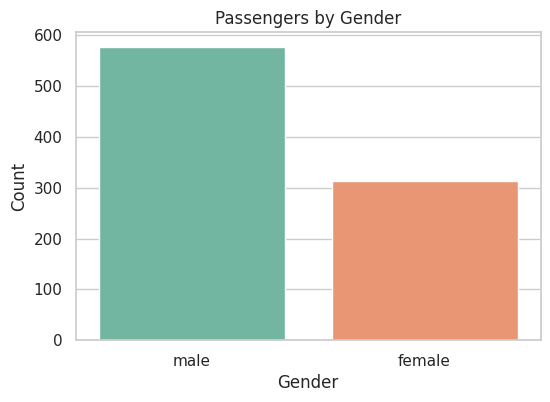

In [ ]:
# Q1. Countplot: Passengers by Gender
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sex", hue="sex", palette="Set2" )
plt.title("Passengers by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

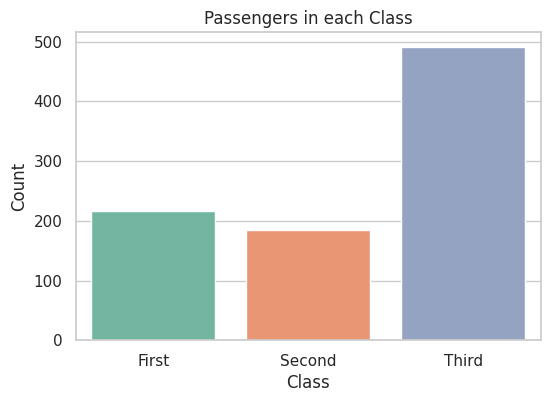

In [ ]:
# Q2. Bar Chart: Passengers in each Class
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="class", hue="class", palette="Set2")
plt.title("Passengers in each Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

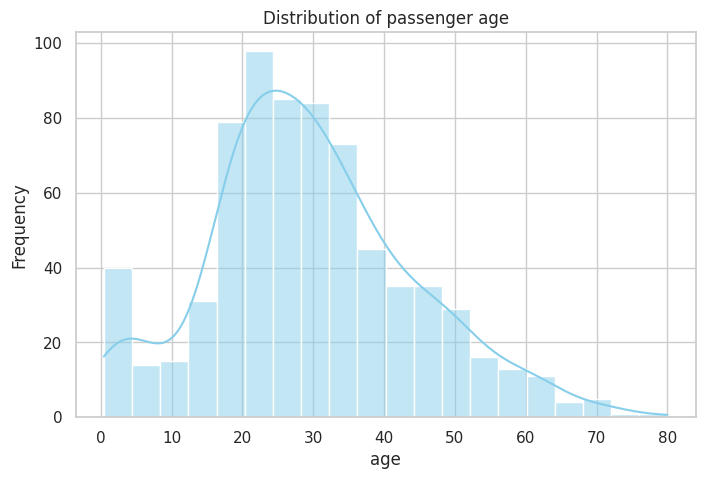

In [3]:
# Q3. Histogram: Distribution of Passenger Age
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", kde=True, color="skyblue")
plt.title("Distribution of passenger age")
plt.xlabel("age")
plt.ylabel("Frequency")
plt.show()


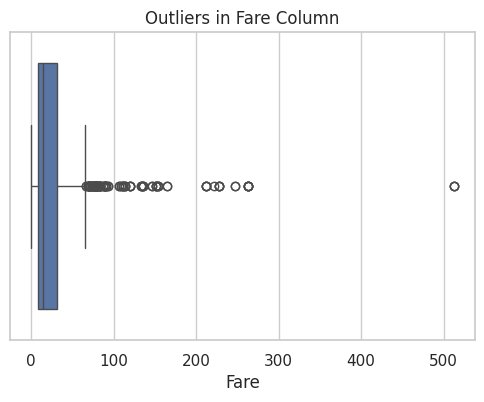

In [12]:
# Q4. Boxplot for Outliers in Fare Column
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="fare")
plt.title("Outliers in Fare Column")
plt.xlabel("Fare")
plt.show()

Text(0, 0.5, 'Fare')

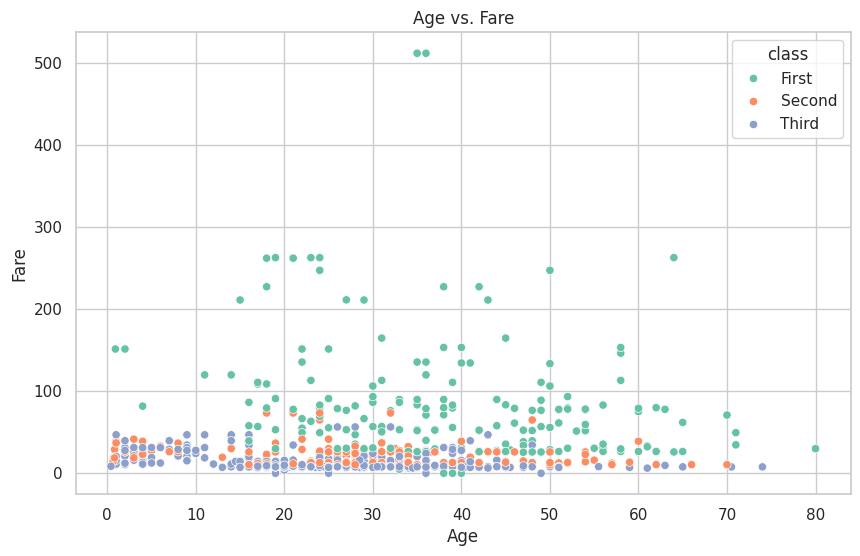

In [16]:
# Q5. Scatterplots (Age vs. Fare & Family Size vs. Fare)
# age vs fare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="age", y="fare", hue="class", palette="Set2")
plt.title("Age vs. Fare")
plt.xlabel("Age")
plt.ylabel("Fare")


Text(0.5, 0, 'family_size')

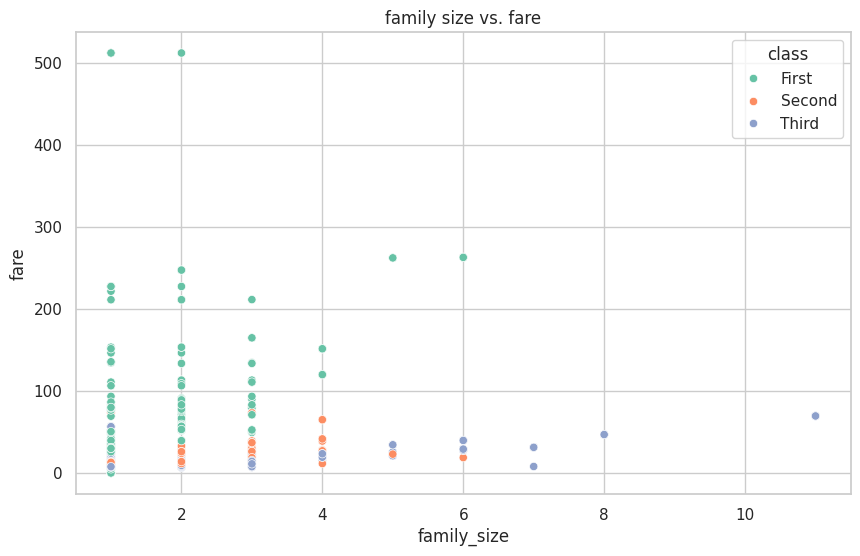

In [36]:
# b. Family Size vs Fare
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="family_size", y="fare", hue="class", palette="Set2")
plt.title("family size vs. fare")
plt.xlabel("family_size")

Text(0, 0.5, 'Count')

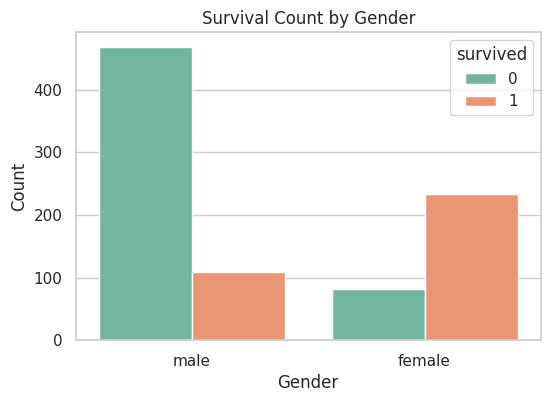

In [37]:
# Q6. Countplot of Survival Count by Gender
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex", hue="survived", palette="Set2")
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

Text(0, 0.5, 'Count')

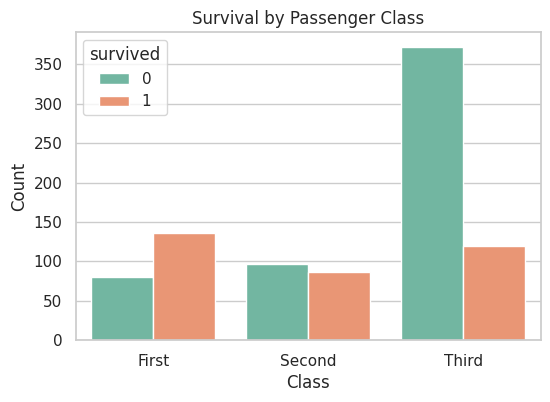

In [38]:
# Q7. Bar Chart of Survival by Passenger Class
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="class", hue="survived", palette="Set2")
plt.title("Survival by Passenger Class")
plt.xlabel("Class")
plt.ylabel("Count")
#

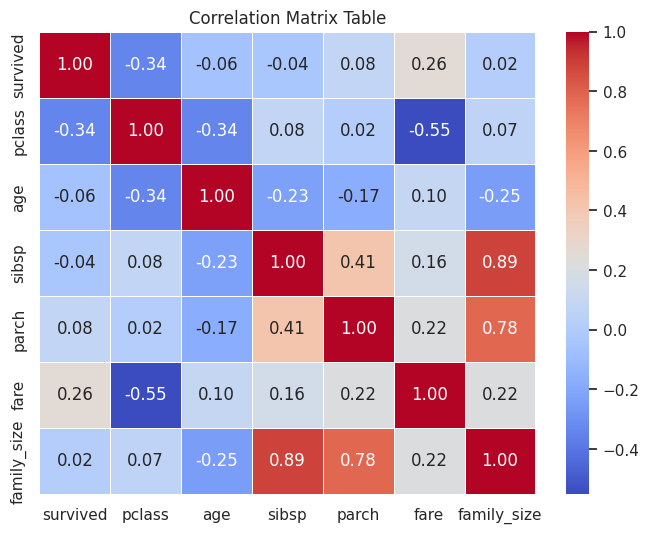

In [41]:
# Q8. Heatmap of Correlation Between Numerical Variable
plt.figure(figsize=(8, 6))
# Select only numerical columns for correlation calculation
numerical_df = df.select_dtypes(include=[np.number])
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix Table')
plt.show()


In [46]:
# Q9. Passenger Class with Highest Average Fare
avg_fare_per_class = df.groupby('pclass')['fare'].mean()
print("--- Average Fare per Passenger Class ---")
print(avg_fare_per_class)
print(f"\nClass {avg_fare_per_class.idxmax()} paid the highest fare on average.")


--- Average Fare per Passenger Class ---
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64

Class 1 paid the highest fare on average.


# Q10. Write at least 5 insights from the dataset based on your visualizations.
**1.Gender Bias in Survival:** Females possessed a dramatically higher survival rate compared to males, validating that rescue protocols prioritised gender during evacuation.
**2.Socioeconomic Status Impact:** Passenger class served as an influential indicator for survival; 1st-class individuals experienced preferential evacuation access compared to lower classes.
**3.Fare Structure Inequity:** The fare metric contains strong positive outliers, showing a small minority paid extreme premium pricing tiers for luxury upper deck space.**4.Demographic Profile:** The typical Titanic traveler was a young adult male between 20 and 35 years old, primarily staying within standard budget 3rd-class tiers.
**5.Family Group Dynamic:** Large families encountered lower survival dynamics, while solo or pairs of passengers buying premium-tier fares retained overall stronger survival metrics